## MINIMUM SPANNING TREE FROM RETURNS

In [2]:
%load_ext autoreload
%autoreload 2

# Standard library imports

# Third-party imports
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import riskfolio as rp

### Setup

This reproduces §13.1.4.1 "Minimum Spanning Tree" from *Advanced Portfolio Optimization*
(Cajas), Ch. 13 "Graph Theory-Based Portfolios" (`../assets/advanced-portfolio-optimization-cajas.pdf`).

The book's claim: the MST is built from a **codependence matrix derived from returns**
(Pearson correlation, in its Python example), which is then transformed into a
**distance matrix**, from which the MST is computed. Confirmed by reading Riskfolio-Lib's
own source (`PlotFunctions.py::plot_network`): for `codependence="pearson"` it uses
Mantegna's (1999) distance

$$D_{i,j} = \sqrt{0.5 (1 - \rho_{i,j})}$$

and then calls `networkx.minimum_spanning_tree` on the complete graph weighted by $D$.

Instead of downloading price data, we simulate 30 assets with geometric Brownian motion
(GBM), grouped into 5 sectors of 6 assets each. Each sector shares a common driving
Brownian motion (high within-sector correlation), and sectors are weakly correlated with
each other -- a synthetic stand-in for the sector clustering real markets exhibit, so the
MST has non-trivial structure to recover.

In [3]:
rng = np.random.default_rng(42)

n_sectors = 5
assets_per_sector = 6
n_assets = n_sectors * assets_per_sector
sectors = np.repeat([f"sector_{s}" for s in range(n_sectors)], assets_per_sector)
assets = [f"{sectors[i]}_asset_{i % assets_per_sector}" for i in range(n_assets)]

within_sector_corr = 0.7
across_sector_corr = 0.15

same_sector = sectors[:, None] == sectors[None, :]
corr = np.where(same_sector, within_sector_corr, across_sector_corr)
np.fill_diagonal(corr, 1.0)

n_periods = 500
dt = 1 / 252
mu = 0.08
sigma = 0.25

chol = np.linalg.cholesky(corr)
independent = rng.standard_normal((n_periods, n_assets))
correlated_shocks = independent @ chol.T

log_returns = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * correlated_shocks
prices = 100 * np.exp(np.cumsum(log_returns, axis=0))

returns = pd.DataFrame(log_returns, columns=assets)
returns.head()

,sector_0_asset_0,sector_0_asset_1,sector_0_asset_2,sector_0_asset_3,sector_0_asset_4,sector_0_asset_5,sector_1_asset_0,sector_1_asset_1,sector_1_asset_2,sector_1_asset_3,...,sector_3_asset_2,sector_3_asset_3,sector_3_asset_4,sector_3_asset_5,sector_4_asset_0,sector_4_asset_1,sector_4_asset_2,sector_4_asset_3,sector_4_asset_4,sector_4_asset_5
0,0.004992,-0.008144,0.006428,0.010201,-0.015571,-0.012594,0.001648,-0.002512,-0.000586,-0.008822,...,0.007463,0.002143,0.018983,0.008000,-0.004822,-0.006650,0.001135,0.000836,0.001995,0.002817
1,0.033921,0.019232,0.016671,0.012412,0.024471,0.030269,0.002953,-0.005923,-0.008790,0.003576,...,0.013792,0.017867,-0.000834,0.007529,-0.002736,-0.007559,-0.006113,0.010521,-0.009104,0.006731
2,-0.026309,-0.022125,-0.018241,-0.013676,-0.011333,-0.009427,-0.008624,-0.012137,-0.000287,-0.008397,...,0.004247,-0.005558,-0.003991,-0.004741,-0.023101,-0.011789,-0.019830,-0.016290,-0.011798,-0.011360
3,0.010672,0.006421,0.002734,0.005026,-0.010484,-0.010921,-0.020246,-0.025086,-0.014378,-0.026155,...,0.001431,0.000596,-0.006880,-0.015812,-0.002864,-0.009130,-0.003225,-0.004705,0.010410,-0.004328
4,-0.015925,-0.009073,-0.008005,0.003723,0.001383,-0.001774,0.021862,0.001510,0.002846,-0.001582,...,0.038021,0.025317,0.012495,0.031632,-0.008385,-0.009029,-0.012516,-0.009437,0.001803,-0.005038


### Step 1 -- returns to codependence matrix

With 30 assets the full matrix is too dense to eyeball, so we only spot-check that the
within-sector block (`sector_0`) is much more correlated than the cross-sector average.

In [4]:
codep = returns.corr(method="pearson")

sector_0_assets = [a for a in assets if a.startswith("sector_0")]
other_assets = [a for a in assets if not a.startswith("sector_0")]

within_avg = codep.loc[sector_0_assets, sector_0_assets].to_numpy()
within_avg = within_avg[~np.eye(len(sector_0_assets), dtype=bool)].mean()
across_avg = codep.loc[sector_0_assets, other_assets].to_numpy().mean()

print(f"sector_0 within-sector average correlation: {within_avg:.2f}")
print(f"sector_0 cross-sector average correlation:  {across_avg:.2f}")

sector_0 within-sector average correlation: 0.70
sector_0 cross-sector average correlation:  0.19


### Step 2 -- codependence matrix to distance matrix

Pearson correlation is a similarity, not a distance (it does not shrink toward 0 as
assets become more alike). Mantegna's transform fixes that: $\rho=1 \Rightarrow D=0$,
$\rho=-1 \Rightarrow D=1$, and $D$ satisfies the triangle inequality, so a shortest-path
algorithm like MST is well-defined on it.

In [4]:
dist = np.sqrt(0.5 * (1 - codep))
dist.iloc[:5, :5]

,sector_0_asset_0,sector_0_asset_1,sector_0_asset_2,sector_0_asset_3,sector_0_asset_4
sector_0_asset_0,0.000000,0.385875,0.388379,0.403358,0.392251
sector_0_asset_1,0.385875,0.000000,0.378790,0.393676,0.366928
sector_0_asset_2,0.388379,0.378790,0.000000,0.398541,0.376468
sector_0_asset_3,0.403358,0.393676,0.398541,0.000000,0.393842
sector_0_asset_4,0.392251,0.366928,0.376468,0.393842,0.000000


### Step 3 -- distance matrix to MST

Build the complete graph on the 30 assets weighted by distance, then keep only the
edges that minimize total edge weight (`networkx.minimum_spanning_tree`, Kruskal by
default). This is exactly what `rp.plot_network` does internally for any `linkage`
other than `"DBHT"`.

In [5]:
T = nx.from_pandas_adjacency(dist)
mst = nx.minimum_spanning_tree(T)

degree = pd.Series(dict(mst.degree()), name="degree").sort_values(ascending=False)
print(
    f"MST has {mst.number_of_edges()} edges for {mst.number_of_nodes()} nodes (n - 1, as expected)"
)
print("\ntop 5 nodes by degree (hubs):")
print(degree.head())
print("\nbottom 5 nodes by degree (periphery):")
print(degree.tail())

MST has 29 edges for 30 nodes (n - 1, as expected)

top 5 nodes by degree (hubs):
sector_2_asset_2    4
sector_0_asset_4    4
sector_4_asset_2    4
sector_4_asset_5    3
sector_1_asset_1    3
Name: degree, dtype: int64

bottom 5 nodes by degree (periphery):
sector_2_asset_0    1
sector_1_asset_3    1
sector_1_asset_2    1
sector_0_asset_2    1
sector_2_asset_3    1
Name: degree, dtype: int64


Hubs concentrate within a sector: once a sector's first asset links into the tree, the
rest of that sector attaches to it cheaply (small within-sector distance), so hub degree
tracks sector size rather than being spread evenly across all 30 assets. Periphery assets
(degree 1) are the ones to prefer for diversification, per the book -- they are least
related to the rest of the portfolio.

### Cross-check with Riskfolio-Lib

`rp.plot_network` reproduces Listing 13.6 from the book directly: pass it `returns`, and
it computes the codependence matrix, the distance matrix, and the MST internally.

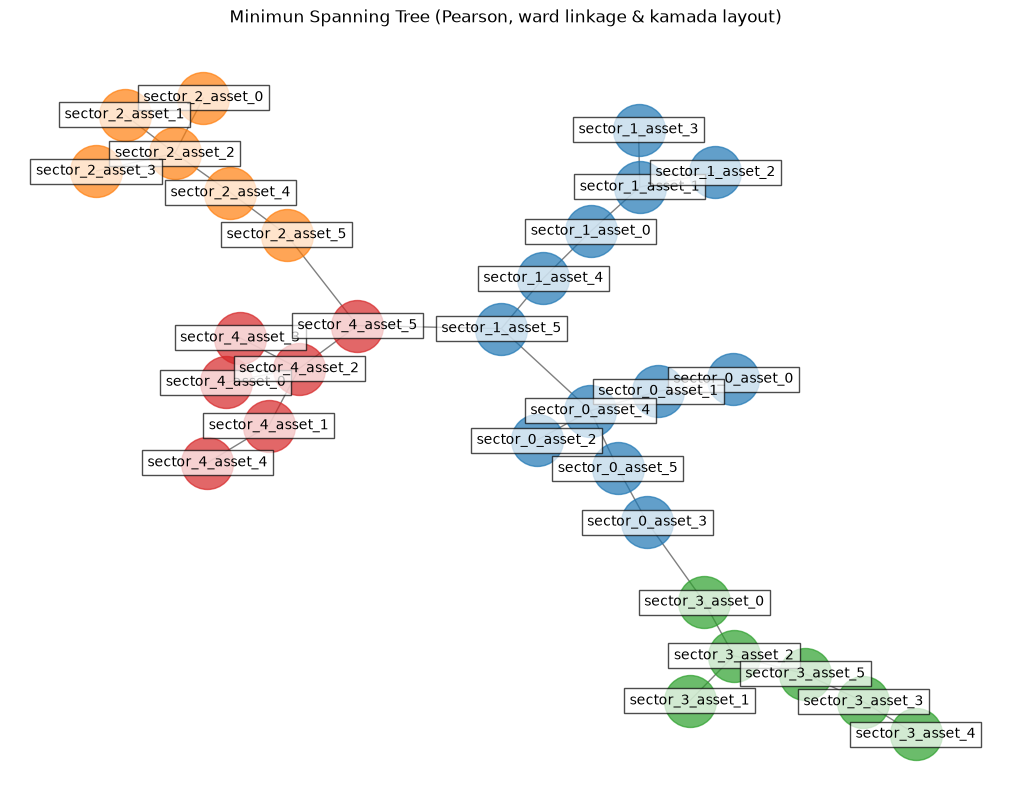

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
ax = rp.plot_network(
    returns=returns,
    codependence="pearson",
    linkage="ward",
    kind="kamada",
    title="",
    ax=ax,
)
plt.show()